# 1 - Dataset Overview

This notebook summarizes dataset composition, protocol, and collection timeline across waves.

Visuals: overview table · participant flow diagram · study timeline

## Import libraries and define paths

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

%matplotlib inline

np.random.seed(42)

from utils import (
    GENDER_COLORS, COLORS, WAVE_LABELS, WAVE_KEYS,
    get_data_root, get_pkl_paths, set_paper_style,
)

DATA_ROOT = get_data_root()
FILES = get_pkl_paths(DATA_ROOT)
set_paper_style()


## Helper functions

In [2]:
from pathlib import Path

from utils import (
    extract_gender, load_esm_28d, load_label_pickle_with_meta,
    load_sensor_28d,
)

# ── Dataset paths for label loading ─────────────────────────────────────────
DATA_ROOT_LABELS = Path(DATA_ROOT)
DATASETS = {
    "D-1": DATA_ROOT_LABELS / "D-1" / "full",
    "D-2": DATA_ROOT_LABELS / "D-2" / "full",
    "D-3": DATA_ROOT_LABELS / "D-3" / "full",
}


def load_label_with_meta(dataset_path, label_nm):
    """Locate the matching ``{label}_personal-full*.pkl`` and load it."""
    pkl_path = next(dataset_path.glob(f"{label_nm}_personal-full*.pkl"))
    return load_label_pickle_with_meta(pkl_path)


def load_user_traits(dataset_path, label_nm, threshold=None, lo_pct=33, hi_pct=67):
    """Return per-user low/high trait splits for a single label."""
    y, pcode, _ts = load_label_with_meta(dataset_path, label_nm)
    user_means_arr = pd.Series(y).groupby(pcode).mean()
    if threshold is None:
        lo = np.percentile(user_means_arr, lo_pct)
        hi = np.percentile(user_means_arr, hi_pct)
    else:
        lo = hi = threshold
    return user_means_arr[user_means_arr <= lo], user_means_arr[user_means_arr >= hi]


## Data loading helpers

In [3]:
# ── ESM, UserInfo, sensors with 28-day window in one shot ──────────────────
esm_by_wave, userinfo_by_wave, esm_all_28d, esm_by_wave_28d, esm_28d_stats = load_esm_28d(
    wave_keys=WAVE_KEYS,
    data_root=DATA_ROOT,
    include_userinfo=True,
    include_study_day=True,
)

df_X_28d, df_X_28d_stats = load_sensor_28d(DATA_ROOT, wave_keys=WAVE_KEYS)


---
## Visuals

### Participant Flow Diagram

Insight: Shows how many participants were recruited, completed, and excluded per wave.

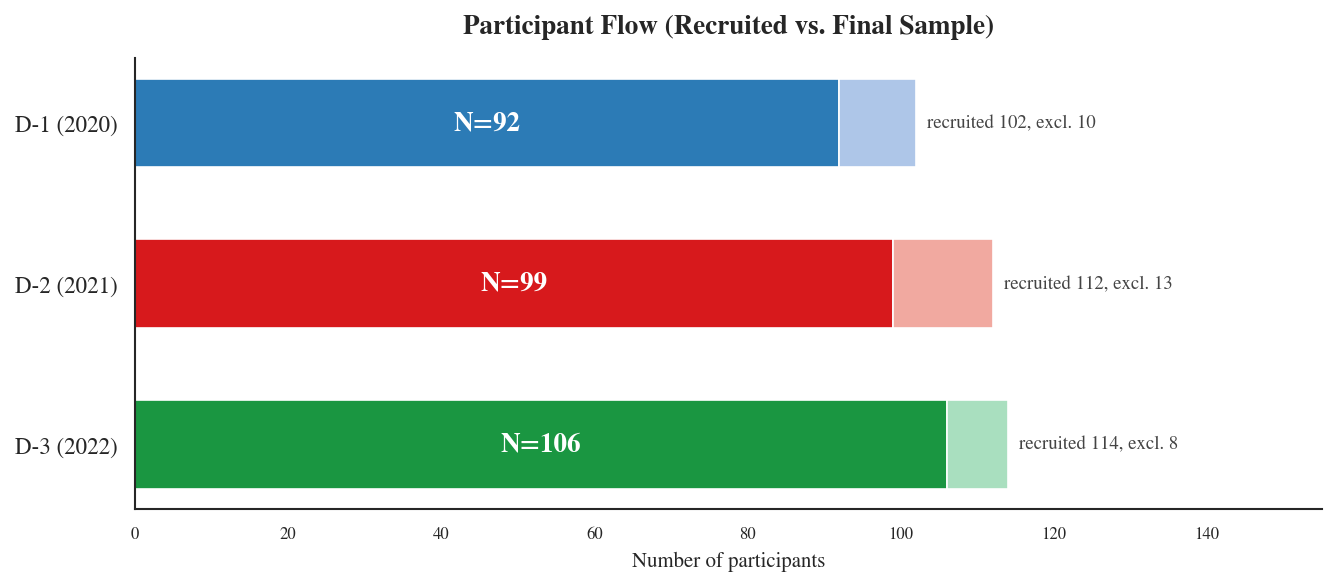

In [4]:
# Participant counts
recruited = [userinfo_by_wave[k].shape[0] for k in WAVE_KEYS]
final = [esm_by_wave_28d[k]["Pcode"].nunique() for k in WAVE_KEYS]
excluded = [r - f for r, f in zip(recruited, final)]

# --- Colors (dark = final, light = excluded) ---
colors_dark  = ["#2C7BB6", "#D7191C", "#1A9641"]   # blue, red, green
colors_light = ["#AEC6E8", "#F1A9A0", "#A9DFBF"]   # matching pastels

fig, ax = plt.subplots(figsize=(9, 4))

y_pos = np.arange(len(WAVE_KEYS))
bar_height = 0.55

for i, (f, e, cd, cl) in enumerate(zip(final, excluded, colors_dark, colors_light)):
    # Main (final) bar
    ax.barh(y_pos[i], f, height=bar_height, color=cd, zorder=2)
    # Excluded extension (stacked)
    ax.barh(y_pos[i], e, height=bar_height, left=f, color=cl, zorder=2)

    # N= label inside the dark bar
    ax.text(f / 2, y_pos[i], f"N={f}", ha="center", va="center",
            fontsize=13, fontweight="bold", color="white", zorder=3)

    # Annotation to the right
    r = f + e
    ax.text(r + 1.5, y_pos[i], f"recruited {r}, excl. {e}",
            va="center", fontsize=9, color="#444444")

# --- Axes formatting ---
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{lbl}" for k, lbl in zip(WAVE_KEYS, WAVE_LABELS)],
                   fontsize=11)
ax.set_xlabel("Number of participants", fontsize=10)
ax.set_xlim(0, 155)
ax.set_title("Participant Flow (Recruited vs. Final Sample)",
             fontweight="bold", fontsize=13, pad=12)

# Remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis() 

plt.tight_layout()
plt.show()


### Age-Gender Distribution

Insight: Age and gender distribution of the combined study sample.

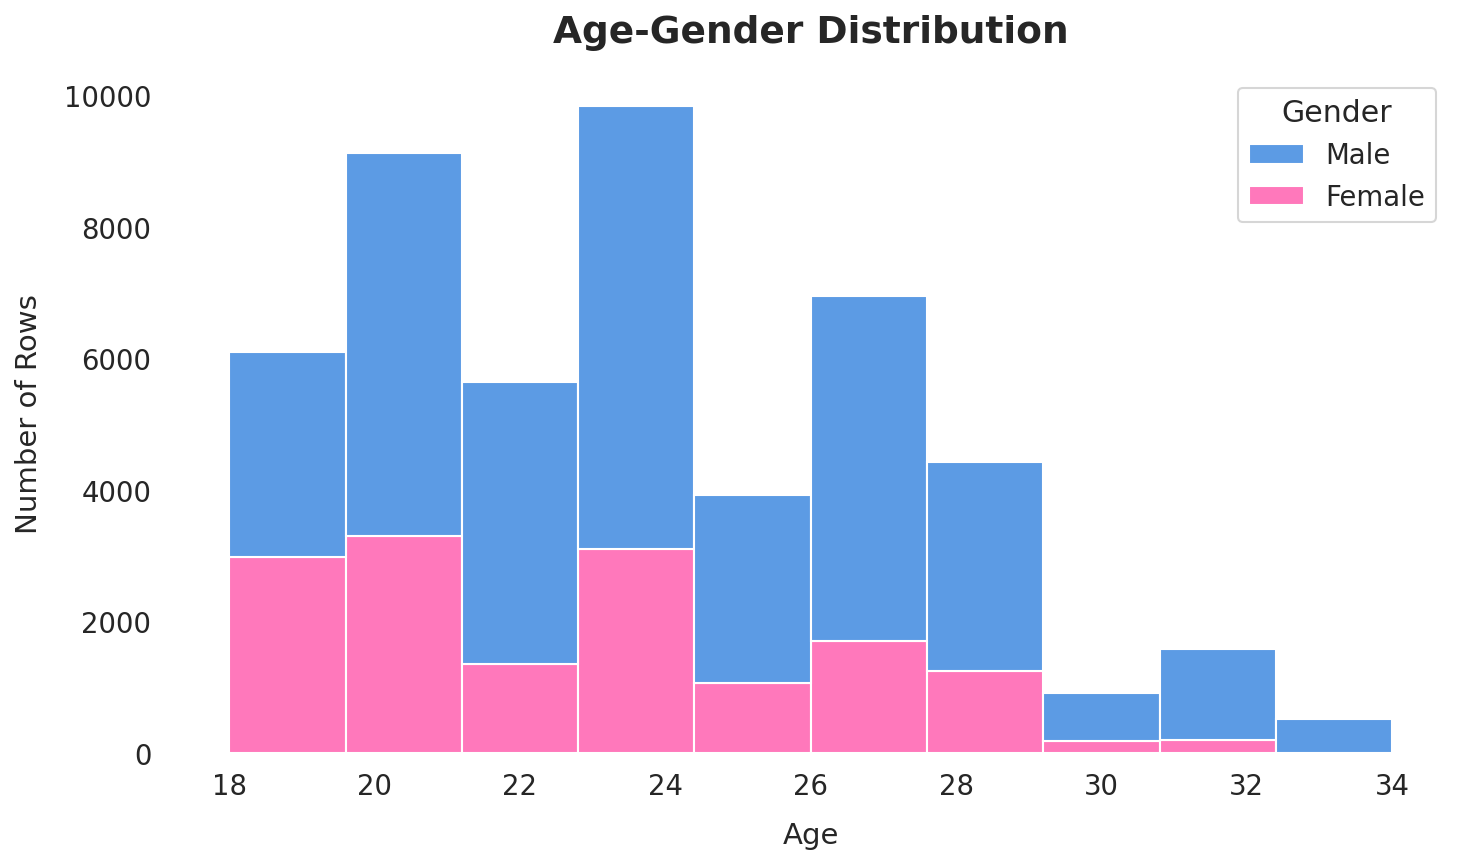

In [5]:
sns.set_theme(style="white", font_scale=1.2)
plt.figure(figsize=(10, 6), dpi=150)

ax = sns.histplot(
    data=df_X_28d,
    x="PIF#age",
    hue="PIF#gender",
    multiple="stack",
    bins=10,
    palette=GENDER_COLORS,
    edgecolor="white",
    alpha=0.9
)

legend = ax.get_legend()
legend.set_title("Gender")

for text in legend.texts:
    if text.get_text() == "M":
        text.set_text("Male")
    elif text.get_text() == "F":
        text.set_text("Female")

plt.title("Age-Gender Distribution", fontsize=18, weight="bold", pad=15)
plt.xlabel("Age", fontsize=14, labelpad=10)
plt.ylabel("Number of Rows", fontsize=14, labelpad=10)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Participant Demographics
Insight: Summary statistics for age and gender per wave.

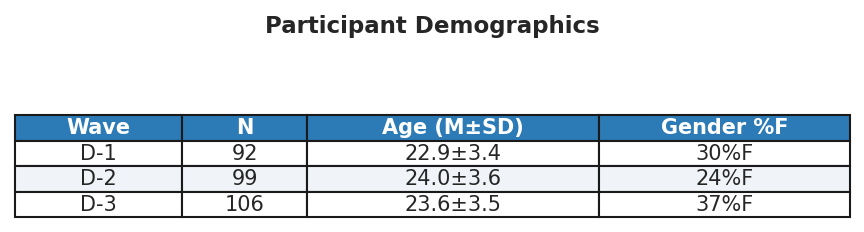

In [6]:
table_data = []
for wave in WAVE_KEYS:
    ui = userinfo_by_wave.get(wave)
    if ui is None or ui.empty:
        continue

    id_col = next((c for c in ui.columns if c.lower() == "pcode"), None)
    esm_df = esm_by_wave_28d.get(wave)
    if id_col and esm_df is not None and not esm_df.empty and "Pcode" in esm_df.columns:
        final_ids = set(esm_df["Pcode"].dropna().unique())
        ui = ui[ui[id_col].isin(final_ids)]

    n = ui[id_col].nunique() if id_col else len(ui)
    age_col = "PIF#age" if "PIF#age" in ui.columns else ("Age" if "Age" in ui.columns else None)

    age_mean = age_std = "-"
    if age_col and age_col in ui.columns:
        ages = ui[age_col].dropna()
        if len(ages) > 0:
            age_mean = f"{ages.mean():.1f}"
            age_std = f"{ages.std():.1f}"

    gender_pct = "-"
    if "Gender" in ui.columns:
        gender = ui["Gender"].astype(str).str.upper()
        gender = gender.where(gender.isin(["M", "F"]))
        total = gender.notna().sum()
        if total > 0:
            pct = (gender == "F").sum() / total * 100
            gender_pct = f"{pct:.0f}%F"

    table_data.append({"Wave": wave, "N": n, "Age (M±SD)": f"{age_mean}±{age_std}", "Gender %F": gender_pct})

if table_data:
    table_df = pd.DataFrame(table_data)
    fig, ax = plt.subplots(figsize=(6, 1.5))
    ax.axis("off")
    tbl = ax.table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc="center",
        loc="center",
        colWidths=[0.2, 0.15, 0.35, 0.3]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.8)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#2C7BB6")
            cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#F0F4F8")
        else:
            cell.set_facecolor("white")
    plt.suptitle("Participant Demographics", fontsize=11, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("No demographics data available")

### ESM Response Time-of-Day Distribution

Insight: When during the day participants respond to ESM prompts.

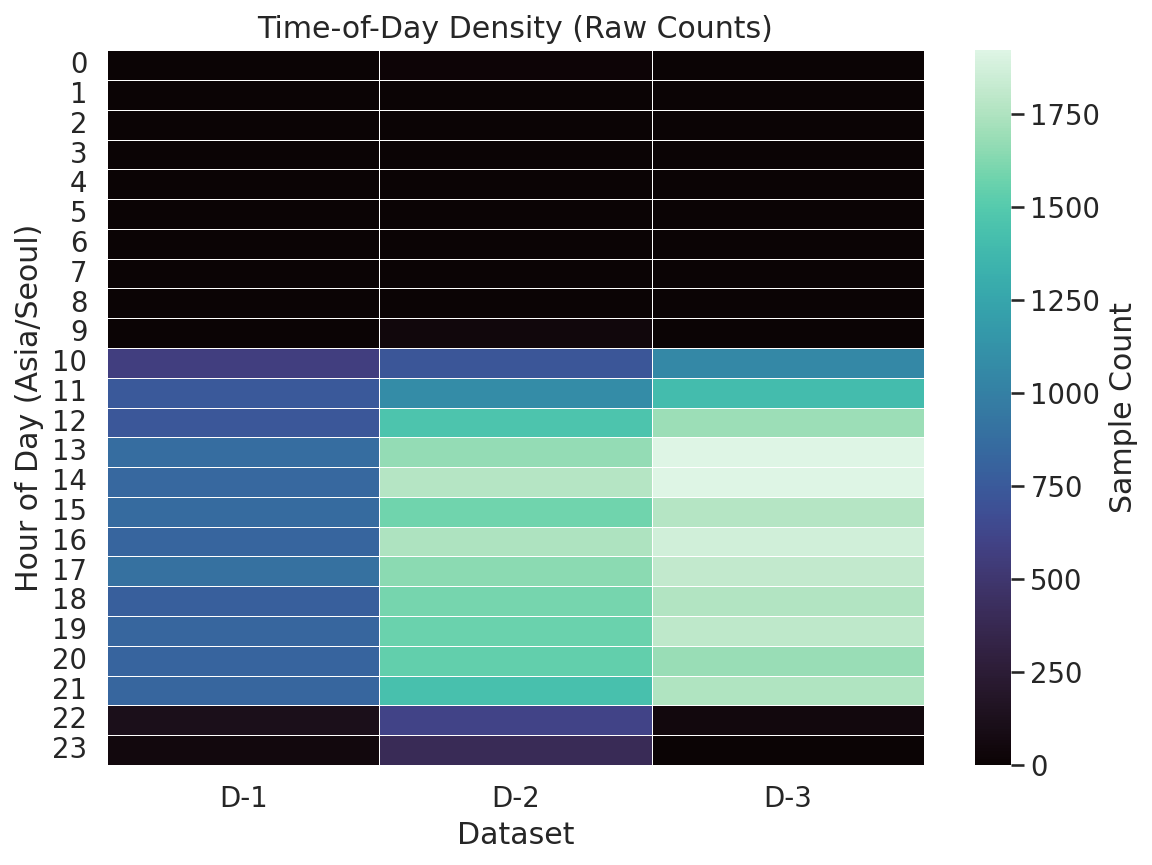

In [7]:
ts_col = "PIF#timestamp"
dt_local = robust_to_utc_datetime(df_X_28d[ts_col]).dt.tz_convert("Asia/Seoul")

df_hour = (
    df_X_28d
      .assign(datetime=dt_local)
      .loc[dt_local.notna(), ["META#dataset", "datetime"]]
      .assign(hour=lambda d: d["datetime"].dt.hour)
)

counts = (
    df_hour
      .groupby(["hour", "META#dataset"])
      .size()
      .unstack(fill_value=0)
      .reindex(range(24), fill_value=0)
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    counts,
    cmap="mako",
    cbar_kws={"label": "Sample Count"},
    linewidths=0.3,
    linecolor="white"
)
plt.title("Time-of-Day Density (Raw Counts)")
plt.xlabel("Dataset")
plt.ylabel("Hour of Day (Asia/Seoul)")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Time-of-Day Activity Distribution

Insight: Hourly ESM response distribution across waves, normalised to proportion per wave.

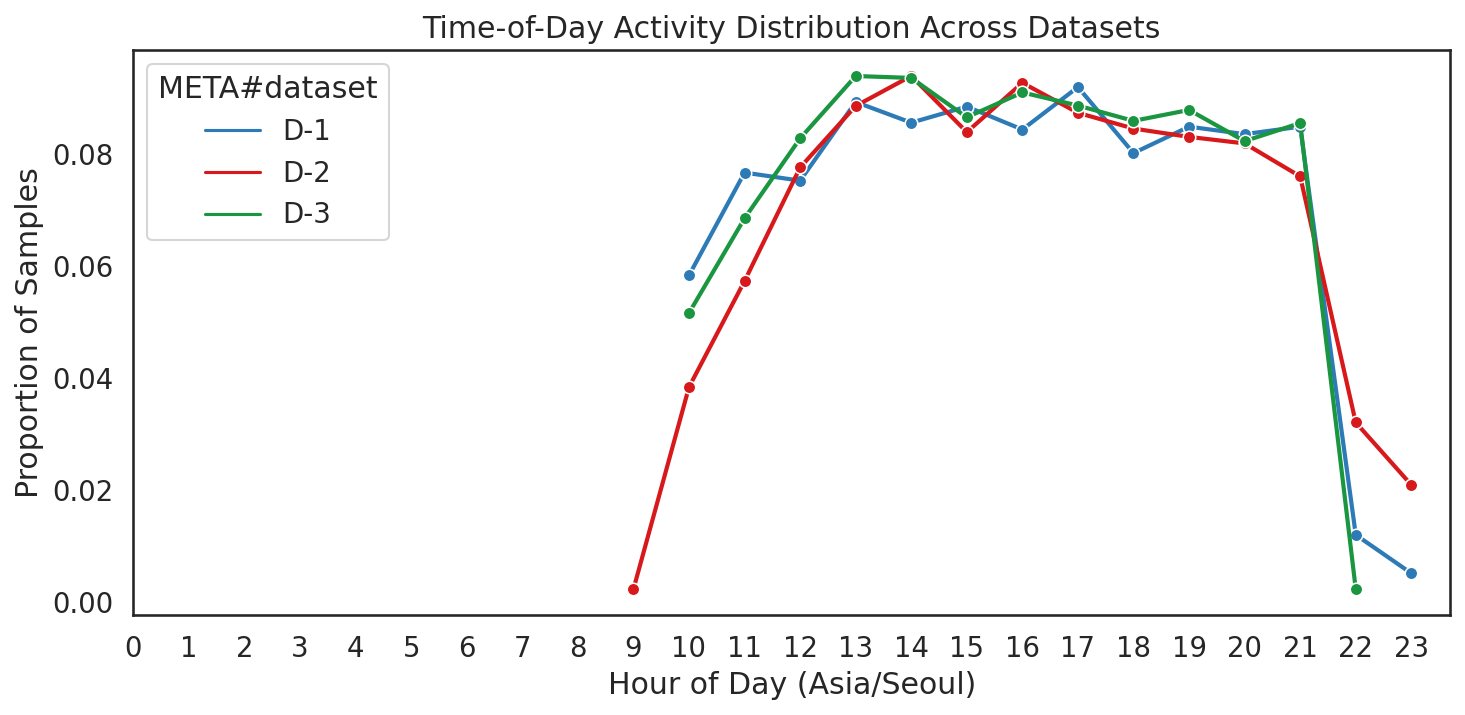

In [8]:
hourly = (
    df_X_28d
        .assign(datetime=dt_local)
        .loc[dt_local.notna()]
        .assign(hour=lambda d: d["datetime"].dt.hour)
        .groupby(["META#dataset", "hour"])
        .size()
        .reset_index(name="sample_count")
)

# keep only hours with ≥ 20 samples per dataset
hourly = hourly[hourly["sample_count"] >= 20]

hourly["proportion"] = (
    hourly.groupby("META#dataset")["sample_count"]
         .transform(lambda x: x / x.sum())
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=hourly,
    x="hour",
    y="proportion",
    hue="META#dataset",
    palette=COLORS,
    marker="o",
    linewidth=2.0,
)
plt.xticks(range(0, 24))
plt.xlabel("Hour of Day (Asia/Seoul)")
plt.ylabel("Proportion of Samples")
plt.title("Time-of-Day Activity Distribution Across Datasets")
plt.tight_layout()
plt.show()

## Participant Demographics

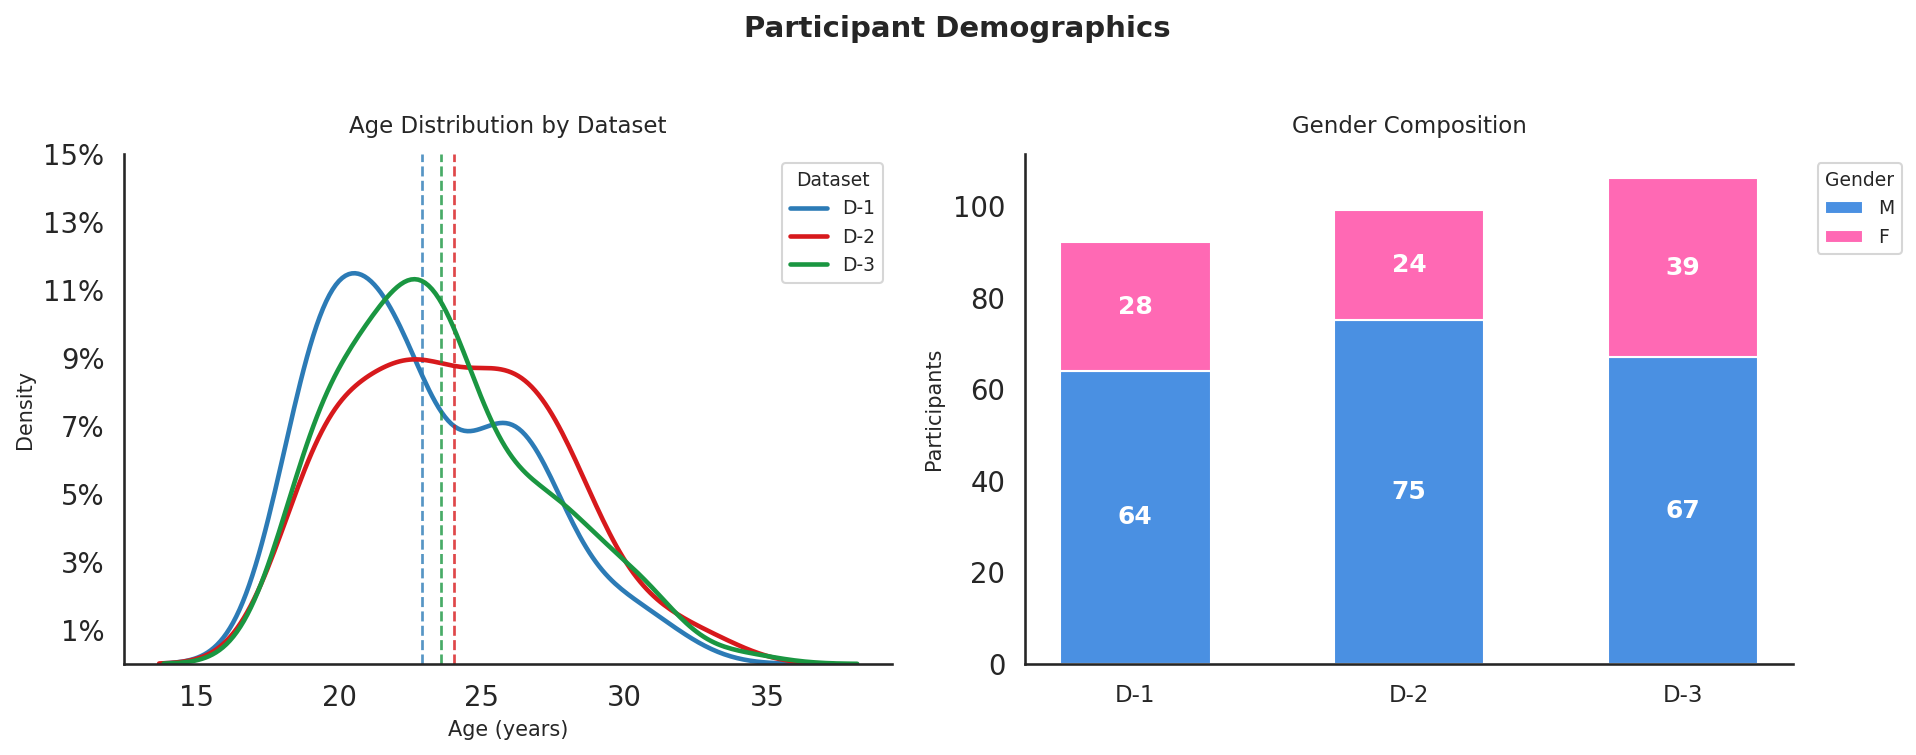

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Participant Demographics", fontweight="bold", fontsize=14, y=1.01)

# ── Build participant-level demographics from df_X_28d ────────────────
demo_df = df_X_28d.copy()
if "PIF#gender" not in demo_df.columns:
    if "PIF#gender=F" in demo_df.columns and "PIF#gender=M" in demo_df.columns:
        demo_df["PIF#gender"] = np.where(
            demo_df["PIF#gender=F"] == 1, "F",
            np.where(demo_df["PIF#gender=M"] == 1, "M", np.nan)
        )

demo_cols = ["META#dataset", "PIF#participantID", "PIF#age", "PIF#gender"]
demo_df = demo_df[[c for c in demo_cols if c in demo_df.columns]].copy()
demo_df = demo_df.drop_duplicates(subset=["META#dataset", "PIF#participantID"])

# ── LEFT: Age Distribution (KDE) ───────────────────────────────────────────
for wave in WAVE_KEYS:
    wave_df = demo_df.loc[demo_df["META#dataset"] == wave]
    if wave_df.empty or "PIF#age" not in wave_df.columns:
        continue
    ages = wave_df["PIF#age"].dropna()
    if ages.empty:
        continue
    sns.kdeplot(
        ages,
        ax=ax1,
        label=wave,
        color=COLORS[wave],
        linewidth=2.2,
        fill=False,
        common_norm=False,
    )

    ax1.axvline(ages.mean(), color=COLORS[wave],
                linestyle="--", linewidth=1.3, alpha=0.8)

ax1.set_title("Age Distribution by Dataset", fontsize=11, pad=10)
ax1.set_xlabel("Age (years)", fontsize=10)
ax1.set_ylabel("Density", fontsize=10)
ax1.set_yticks([0.01, 0.03, 0.05, 0.07, 0.09, 0.11, 0.13, 0.15])
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v * 100)}%"))
ax1.legend(title="Dataset", fontsize=9, title_fontsize=9, frameon=True)
ax1.grid(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ── RIGHT: Gender Composition ─────────────────────────────────────────────
gender_data = []
for wave in WAVE_KEYS:
    wave_df = demo_df.loc[demo_df["META#dataset"] == wave]
    if wave_df.empty or "PIF#gender" not in wave_df.columns:
        continue
    gender = wave_df["PIF#gender"].astype(str).str.upper()
    gender = gender.where(gender.isin(["M", "F"]))
    temp = pd.DataFrame({"Wave": wave, "Gender": gender})
    gender_data.append(temp)

if gender_data:
    gender_df = pd.concat(gender_data, ignore_index=True)
    gender_counts = (gender_df.groupby(["Wave", "Gender"])
                               .size()
                               .unstack(fill_value=0)
                               .reindex(WAVE_KEYS))

    x = np.arange(len(WAVE_KEYS))
    w = 0.55
    male = gender_counts.get("M", pd.Series([0] * len(WAVE_KEYS), index=WAVE_KEYS))
    fem = gender_counts.get("F", pd.Series([0] * len(WAVE_KEYS), index=WAVE_KEYS))

    ax2.bar(x, male, width=w, color=GENDER_COLORS["M"], label="M", zorder=2)
    ax2.bar(x, fem, width=w, bottom=male,
            color=GENDER_COLORS["F"], label="F", zorder=2)

    for i, (m, f) in enumerate(zip(male, fem)):
        if m > 0:
            ax2.text(x[i], m / 2, str(int(m)),
                     ha="center", va="center",
                     color="white", fontweight="bold", fontsize=12)
        if f > 0:
            ax2.text(x[i], m + f / 2, str(int(f)),
                     ha="center", va="center",
                     color="white", fontweight="bold", fontsize=12)

    ax2.set_title("Gender Composition", fontsize=11, pad=10)
    ax2.set_ylabel("Participants", fontsize=10)
    ax2.set_xticks(x)
    ax2.set_xticklabels(WAVE_KEYS, fontsize=11)
    ax2.yaxis.set_major_locator(plt.MultipleLocator(20))
    ax2.legend(title="Gender", fontsize=9, title_fontsize=9, frameon=True,
           loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax2.grid(False)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
else:
    ax2.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.show()


### Stress Drift - Per-User Aligned (All Datasets + Combined)

Insight: Stress label proportions over participation time, per-user aligned with gender breakdown.
Plots individual datasets (D-1, D-2, D-3) and the combined dataset.

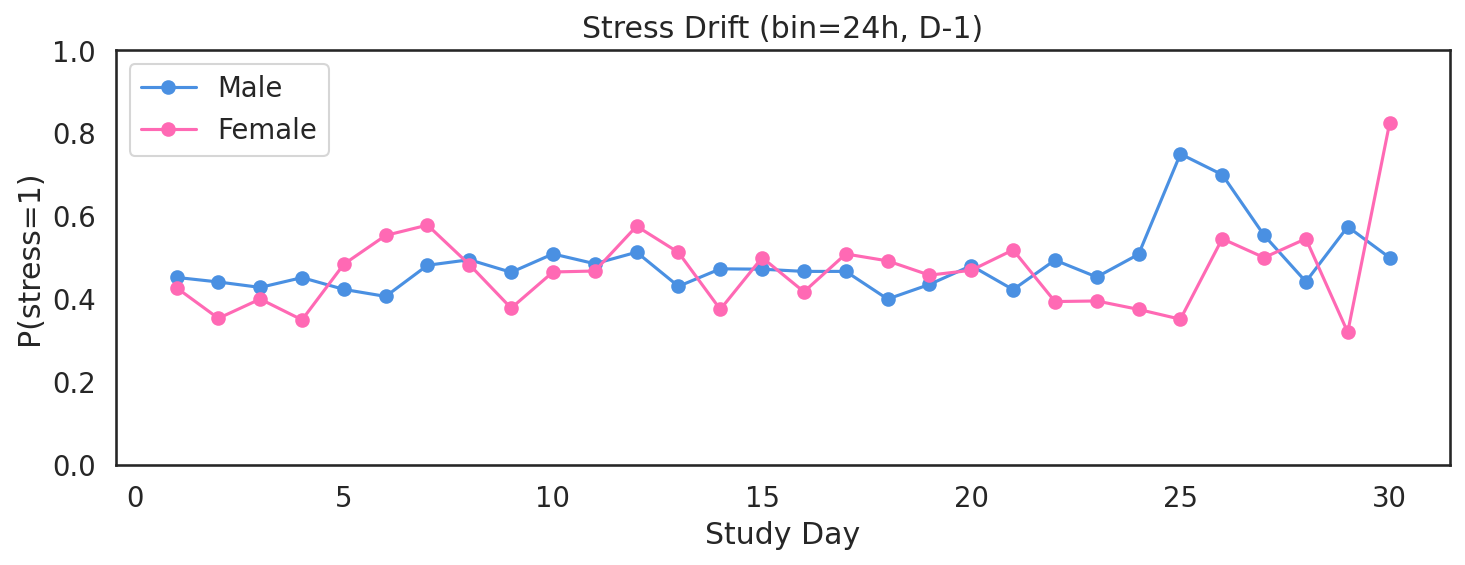

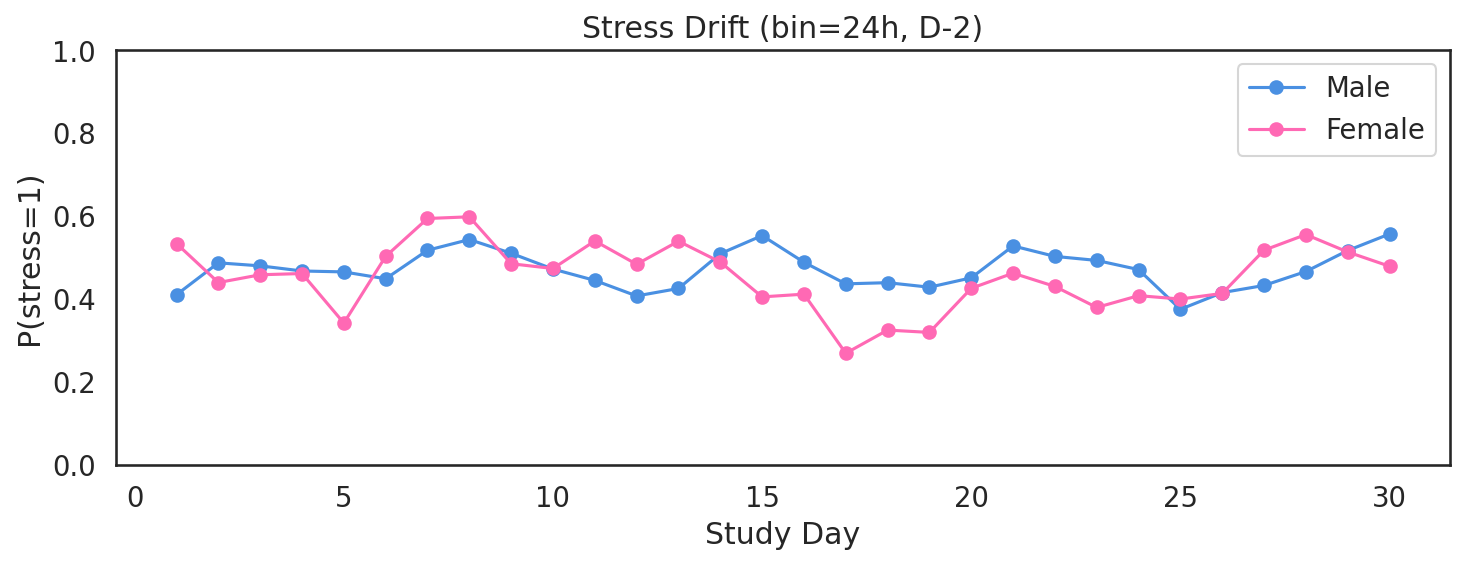

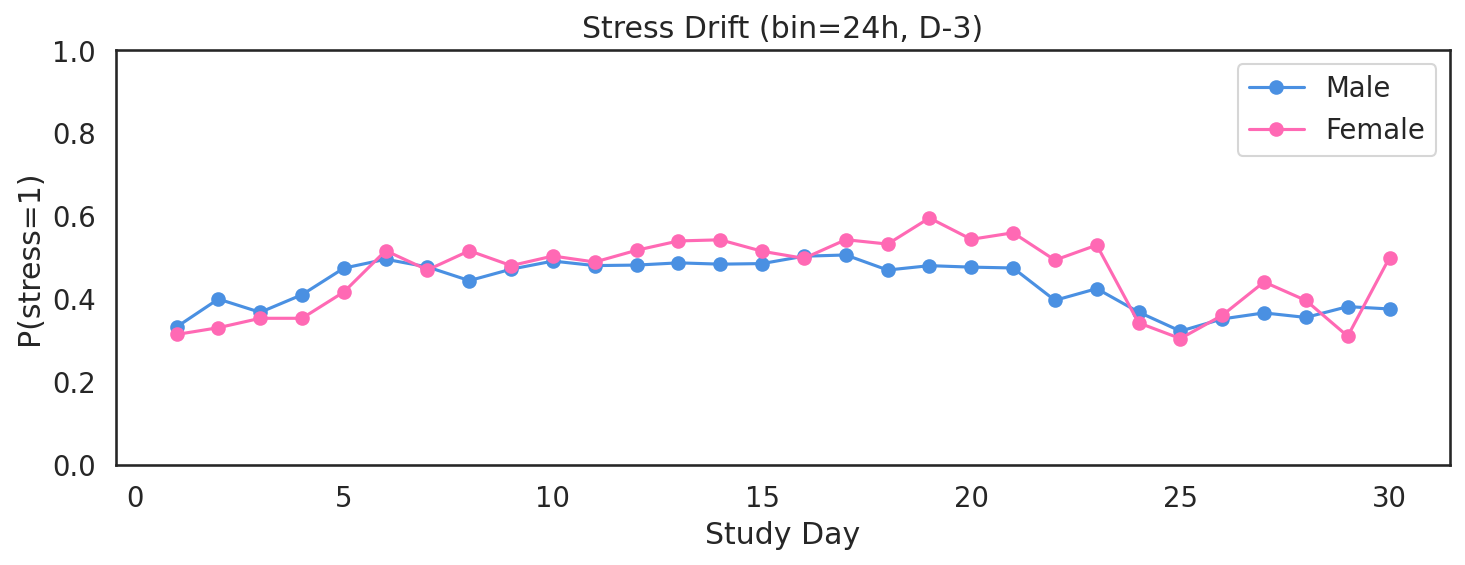

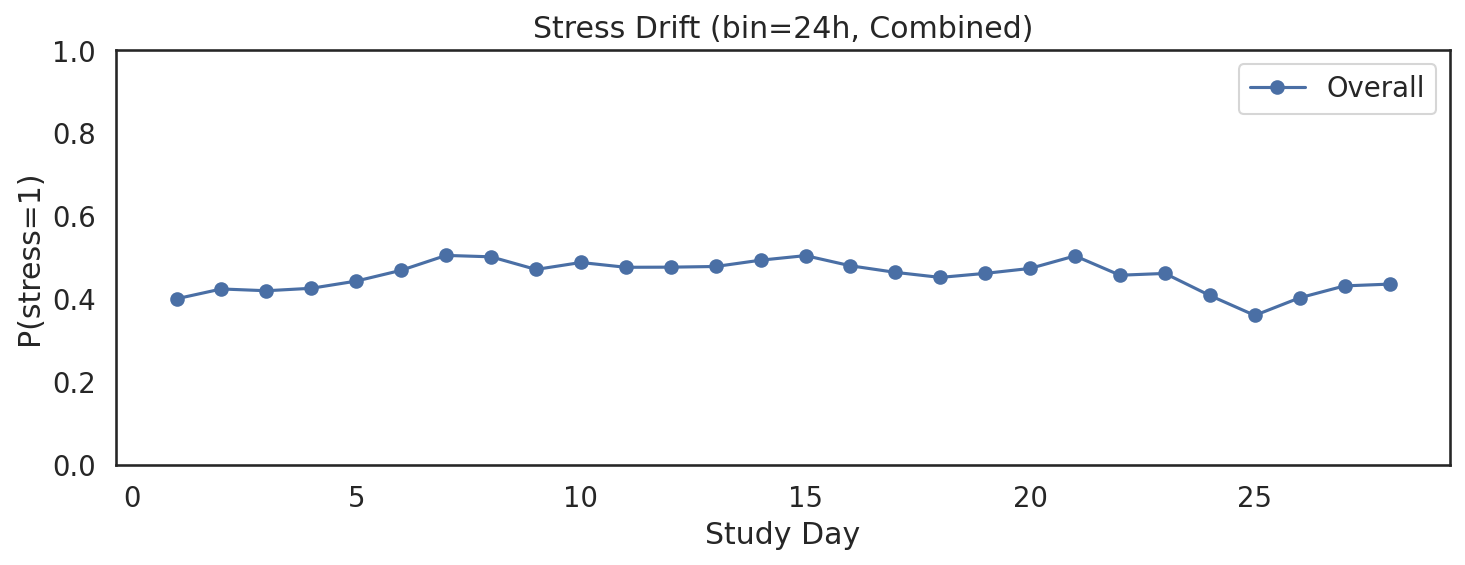

In [10]:
_BIN_HOURS = 24
_WINDOW_DAYS = 30

# ── Build globally anchored metadata per dataset ──────────────────────────────────────────
# Anchor rule: everyone is shifted so their first response date maps to the earliest
_plot_targets = []

for _name, _path in FILES.items():
    _df_raw, _y, _groups, _t, _datetimes = pd.read_pickle(_path)
    _gender = extract_gender(_df_raw) if len(_df_raw) == len(_groups) else pd.Series(np.nan, index=np.arange(len(_groups)))

    _meta = pd.DataFrame({
        "participant_id": _groups,
        "timestamp": pd.to_datetime(_datetimes, errors="coerce"),
        "label": _y,
        "gender": _gender.values,
    }).dropna(subset=["participant_id", "timestamp", "label"])

    if _meta.empty:
        _plot_targets.append((_name, _meta, pd.NaT))
        continue

    _anchor_date = _meta["timestamp"].dt.normalize().min()
    _user_start_date = _meta.groupby("participant_id")["timestamp"].transform(lambda s: s.dt.normalize().min())

    # Shift each user backward/forward by whole-day offset so user start aligns to anchor.
    _day_offset = (_user_start_date - _anchor_date).dt.days
    _meta["aligned_timestamp"] = _meta["timestamp"] - pd.to_timedelta(_day_offset, unit="D")

    _window_end = _anchor_date + pd.Timedelta(days=_WINDOW_DAYS - 1)
    _meta = _meta[
        (_meta["aligned_timestamp"].dt.normalize() >= _anchor_date)
        & (_meta["aligned_timestamp"].dt.normalize() <= _window_end)
    ].copy()

    _meta["aligned_day"] = (_meta["aligned_timestamp"].dt.normalize() - _anchor_date).dt.days + 1
    _plot_targets.append((_name, _meta, _anchor_date))

# ── Combined dataset with the same global-anchor logic ────────────────────────────────────
_df_comb = df_X_28d.copy()
_df_comb["_participant"] = _df_comb["META#dataset"] + "_" + _df_comb["PIF#participantID"].astype(str)

_meta_comb = pd.DataFrame({
    "participant_id": _df_comb["_participant"],
    "timestamp": pd.to_datetime(_df_comb["PIF#timestamp"], errors="coerce"),
    "label": _df_comb["PIF#stress_label"].values,
}).dropna(subset=["participant_id", "timestamp", "label"])

if _meta_comb.empty:
    _plot_targets.append(("Combined", _meta_comb, pd.NaT))
else:
    _anchor_date = _meta_comb["timestamp"].dt.normalize().min()
    _user_start_date = _meta_comb.groupby("participant_id")["timestamp"].transform(lambda s: s.dt.normalize().min())

    _day_offset = (_user_start_date - _anchor_date).dt.days
    _meta_comb["aligned_timestamp"] = _meta_comb["timestamp"] - pd.to_timedelta(_day_offset, unit="D")

    _window_end = _anchor_date + pd.Timedelta(days=_WINDOW_DAYS - 1)
    _meta_comb = _meta_comb[
        (_meta_comb["aligned_timestamp"].dt.normalize() >= _anchor_date)
        & (_meta_comb["aligned_timestamp"].dt.normalize() <= _window_end)
    ].copy()

    _meta_comb["aligned_day"] = (_meta_comb["aligned_timestamp"].dt.normalize() - _anchor_date).dt.days + 1
    _plot_targets.append(("Combined", _meta_comb, _anchor_date))

# ── Plot stress drift ───────────────────────────────────────────────────────────────────────
# Individual waves: Male/Female + Overall
# Combined: Overall only
for _title, _meta, _anchor_date in _plot_targets:
    if _meta.empty:
        print(f"[skip] {_title}: no data after alignment/windowing")
        continue

    _d = _meta[["aligned_day", "label"]].copy()
    if "gender" in _meta.columns:
        _d["gender"] = _meta["gender"].astype(str).str.upper().where(_meta["gender"].astype(str).str.upper().isin(["M", "F"]))

    _d["_bin"] = (((_d["aligned_day"] - 1) * 24) / _BIN_HOURS).astype(int) + 1
    _series = _d.groupby("_bin")["label"].mean()

    plt.figure(figsize=(10, 4))

    if _title == "Combined":
        plt.plot(_series.index, _series.values, marker="o", color="#4A6FA5", label="Overall")
    elif "gender" in _d.columns and _d["gender"].notna().any():
        _by_gender = _d.dropna(subset=["gender"]).groupby(["_bin", "gender"])["label"].mean().unstack()
        if "M" in _by_gender.columns:
            plt.plot(_by_gender.index, _by_gender["M"], marker="o", color=GENDER_COLORS["M"], label="Male")
        if "F" in _by_gender.columns:
            plt.plot(_by_gender.index, _by_gender["F"], marker="o", color=GENDER_COLORS["F"], label="Female")
    else:
        # Fallback: if gender is unavailable in an individual dataset, show overall.
        plt.plot(_series.index, _series.values, marker="o", color="#4A6FA5", label="Overall")

    plt.title(
        f"Stress Drift (bin={_BIN_HOURS}h, {_title})"
    )
    plt.xlabel("Study Day")
    plt.ylabel("P(stress=1)")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()